<a href="https://colab.research.google.com/github/TetianaMar-888/Board-games-analysis/blob/main/notebooks/DM1_03_classification_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Classification & Regression
### Board Games Dataset

This notebook covers:
1. Classification of Rating — including confusion matrix, ROC, test set
2. Regression — simple and multiple, включно з MSE/R²
3. Discussion — best algorithm for each task

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_recall_fscore_support, roc_curve, auc
)

REPORTS = '/content/drive/MyDrive/2_PROJECTS/DM1_25_26/reports'

data_clean = pd.read_parquet('/content/drive/MyDrive/2_PROJECTS/DM1_25_26/data/board_games_cleaned.parquet')
print(data_clean.shape)

Mounted at /content/drive
(21181, 39)


## 1. Classification of Rating


In [ ]:
classification_features = [
    # complexity
    "ComWeight", "ComAgeRec",
    # format
    "MinPlayers", "MaxPlayers", "MfgPlaytime_log",
    # recency — the strongest single separator found in Module 1
    "YearPublished",
    # popularity: one representative only (NumOwned_log correlates 0.95 with it)
    "NumUserRatings_log", "NumWant_log",
    # other
    "NumExpansions", "BestPlayers_known", "Kickstarted", "IsReimplementation",
    # category flags
    "Cat:Thematic", "Cat:Strategy", "Cat:War", "Cat:Family",
    "Cat:CGS", "Cat:Abstract", "Cat:Party", "Cat:Childrens",
]

df_class = data_clean[classification_features + ["Rating"]].dropna()
print("Shape:", df_class.shape)
print(f"Rows lost to listwise deletion: {len(data_clean) - len(df_class)} "
      f"({(1 - len(df_class)/len(data_clean))*100:.1f}%)")

print("\nClass distribution:")
counts = df_class["Rating"].value_counts().reindex(["Low", "Medium", "High"])
print(pd.DataFrame({"n": counts, "%": (counts / len(df_class) * 100).round(1)}))

# Ordinal encoding, set explicitly. LabelEncoder would sort alphabetically
# (High=0, Low=1, Medium=2), which scrambles the confusion matrix: adjacent
# errors such as Low -> Medium would not appear in adjacent cells.
CLASS_ORDER = ["Low", "Medium", "High"]
class_to_int = {c: i for i, c in enumerate(CLASS_ORDER)}

X = df_class[classification_features]
y = df_class["Rating"].map(class_to_int).values

print("\nEncoding:", class_to_int)

Shape: (15487, 21)
Rows lost to listwise deletion: 5694 (26.9%)

Class distribution:
           n     %
Rating            
Low     4329  28.0
Medium  7167  46.3
High    3991  25.8

Encoding: {'Low': 0, 'Medium': 1, 'High': 2}


### Feature selection

Twenty features were selected, covering the dimensions the Module 1 analysis
identified as carrying independent information. Four decisions shaped the list.

**`YearPublished` was added.** The boxplot analysis of Module 1 showed it to be
the strongest single separator of the three classes: mean publication year rises
from 2001 for Low-rated games to 2014 for High-rated ones, with barely
overlapping interquartile ranges. It was absent from an earlier version of this
feature set, which is the most consequential omission the data understanding
phase corrected.

**The popularity block was reduced to two members.** `NumOwned_log`,
`NumUserRatings_log`, `NumWish_log`, `NumWant_log` and `NumWeightVotes_log`
correlate at 0.70–0.95. Retaining all five would give the popularity dimension
five times the weight of complexity in any distance-based model without adding
information. `NumUserRatings_log` was kept as the primary representative — rating
volume is conceptually closest to the rating target itself — together with
`NumWant_log`, the only other member correlating below 0.8 with it (0.77) and
therefore carrying some independent signal about demand as opposed to adoption.

**`MfgAgeRec` was excluded.** It correlates at 0.72 with `ComAgeRec`, repeating
the manufacturer-versus-community duplication pattern already resolved in favour
of the community measure for `GameWeight`/`ComWeight`.

**Three unused binary variables were added**: `BestPlayers_known`, `Kickstarted`
and `IsReimplementation`. They are complete, cheap, and plausibly informative —
crowdfunding and reimplementation status both relate to how a game reached the
market.

Listwise deletion leaves 15,487 games, the same subset used in Module 2, since
the missingness is confined to `ComAgeRec`, `MfgPlaytime_log` and `ComWeight`
while every added feature is complete. Results across the two modules are
therefore computed on identical data.

The class distribution is moderately imbalanced (Medium 46.3%, Low 28.0%,
High 25.8%). This is mild enough that resampling is unnecessary;
`class_weight='balanced'` is instead included among the hyperparameters tested
during grid search, and macro-averaged F1 is used as the selection metric
throughout so that each class contributes equally regardless of its size.

**On potential leakage.** `NumUserRatings_log` and `NumWant_log` count how many
users engaged with a game; they do not encode what those users scored it. The
target is derived from the average rating, which is a different quantity, so
these features are legitimate predictors rather than a leak. The relationship
they capture — popular games tend to be better rated — is a genuine property of
the domain and one of the findings the classification is meant to quantify.

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Train: {X_train.shape[0]:5d}  Val: {X_val.shape[0]:5d}  Test: {X_test.shape[0]:5d}")

props = pd.DataFrame({
    name: pd.Series(arr).value_counts(normalize=True).sort_index()
    for name, arr in [("train", y_train), ("val", y_val), ("test", y_test)]
}).round(3)
props.index = [CLASS_ORDER[i] for i in props.index]

print("\nClass proportions preserved by stratification:")
print(props)

Train: 10840  Val:  2323  Test:  2324

Class proportions preserved by stratification:
        train    val   test
Low     0.280  0.279  0.280
Medium  0.463  0.463  0.463
High    0.258  0.258  0.258


### Train / validation / test split

The data is split 70/15/15 into training (10,840), validation (2,323) and test
(2,324) sets, stratified on the target so that the class proportions are
preserved in each part (Low 28.0%, Medium 46.3%, High 25.8%, matching to three
decimal places).

Three parts rather than two, because model selection happens twice. Cross-
validation on the training set chooses hyperparameters within each algorithm; the
validation set then compares the three tuned algorithms against each other. Both
steps consume information about the data they are evaluated on. The test set is
held out from both and used exactly once, on the single winning model, so that
the figure reported as the final estimate has not influenced any decision.

### Decision Tree

In [ ]:
dt_grid = {
    "clf__criterion":        ["gini", "entropy"],
    "clf__max_depth":        [3, 5, 7, 10, 15, None],
    "clf__min_samples_leaf": [1, 5, 20, 50],
    "clf__class_weight":     [None, "balanced"],
}

dt_pipe = Pipeline([("clf", DecisionTreeClassifier(random_state=42))])
dt_search = GridSearchCV(dt_pipe, dt_grid, scoring="f1_macro", cv=5, n_jobs=-1)
dt_search.fit(X_train, y_train)

print("Configurations tested:", len(dt_search.cv_results_["params"]))
print("Best params:", {k.replace("clf__", ""): v for k, v in dt_search.best_params_.items()})
print("Best CV macro-F1:", round(dt_search.best_score_, 4))

print("\nValidation set:")
print(classification_report(y_val, dt_search.best_estimator_.predict(X_val),
                            target_names=CLASS_ORDER, zero_division=0))

Configurations tested: 96
Best params: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 20}
Best CV macro-F1: 0.6878

Validation set:
              precision    recall  f1-score   support

         Low       0.70      0.65      0.68       649
      Medium       0.66      0.72      0.69      1075
        High       0.75      0.69      0.72       599

    accuracy                           0.69      2323
   macro avg       0.70      0.69      0.69      2323
weighted avg       0.69      0.69      0.69      2323



In [ ]:
dt_best = dt_search.best_estimator_.named_steps["clf"]

imp = (pd.Series(dt_best.feature_importances_, index=classification_features)
         .sort_values(ascending=False))
print(imp[imp > 0.005].round(4))
print(f"\nFeatures with zero importance: {(imp == 0).sum()} of {len(imp)}")

NumWant_log           0.4127
YearPublished         0.2266
ComWeight             0.1823
NumUserRatings_log    0.0508
Cat:War               0.0409
MaxPlayers            0.0208
ComAgeRec             0.0201
MfgPlaytime_log       0.0174
NumExpansions         0.0138
dtype: float64

Features with zero importance: 5 of 20


In [ ]:
# NumWant_log dominates the tree — is it a genuine predictor or a proxy target?
print("Correlation with the target (ordinal encoding):")
for f in ["NumWant_log", "YearPublished", "ComWeight", "NumUserRatings_log"]:
    print(f"  {f:22s} {np.corrcoef(X[f], y)[0,1]:+.3f}")

print("\nMean NumWant_log by class:")
print(df_class.groupby("Rating")["NumWant_log"].agg(["mean", "median", "std"])
        .reindex(CLASS_ORDER).round(2))

# How much does the model rely on it? Refit without it.
feats_no_want = [f for f in classification_features if f != "NumWant_log"]
dt_check = Pipeline([("clf", DecisionTreeClassifier(
    random_state=42, criterion="entropy", max_depth=10, min_samples_leaf=20))])
dt_check.fit(X_train[feats_no_want], y_train)

from sklearn.metrics import f1_score
print("\nMacro-F1 on validation:")
print("  with NumWant_log:   ", round(f1_score(y_val, dt_search.best_estimator_.predict(X_val), average="macro"), 4))
print("  without NumWant_log:", round(f1_score(y_val, dt_check.predict(X_val[feats_no_want]), average="macro"), 4))

Correlation with the target (ordinal encoding):
  NumWant_log            +0.569
  YearPublished          +0.344
  ComWeight              +0.489
  NumUserRatings_log     +0.286

Mean NumWant_log by class:
        mean  median   std
Rating                    
Low     1.56    1.61  0.97
Medium  2.83    2.83  1.26
High    3.96    3.99  1.55

Macro-F1 on validation:
  with NumWant_log:    0.693
  without NumWant_log: 0.655


### Decision Tree: results and feature importance

A grid of 96 configurations was evaluated by 5-fold cross-validation on macro-F1:
`criterion` ∈ {gini, entropy}, `max_depth` ∈ {3, 5, 7, 10, 15, None},
`min_samples_leaf` ∈ {1, 5, 20, 50} and `class_weight` ∈ {None, balanced}. The
best configuration — entropy, depth 10, minimum 20 samples per leaf, unweighted —
reached a cross-validated macro-F1 of 0.688 and 0.693 on the validation set,
with accuracy of 0.69 and per-class F1 between 0.68 and 0.72.

`class_weight='balanced'` lost to the unweighted baseline. With a 46/28/26 split
the imbalance is mild, and reweighting costs more in Medium-class performance
than it recovers on the smaller classes.

Feature importances concentrate sharply — three variables account for 82%:

| Feature | Importance | Correlation with target |
|---|---|---|
| `NumWant_log` | 0.413 | +0.569 |
| `YearPublished` | 0.227 | +0.344 |
| `ComWeight` | 0.182 | +0.489 |
| `NumUserRatings_log` | 0.051 | +0.286 |
| `Cat:War` | 0.041 | — |

Five of the twenty features receive zero importance.

**`NumWant_log` is the dominant predictor, and its status was verified before
being accepted.** The concern is that a variable this strong may be a proxy for
the target rather than a predictor of it. Three checks argue against that
reading. Its correlation with the ordinal target is 0.569 — substantial but far
from deterministic. Its class means separate monotonically (1.56, 2.83, 3.96)
but with standard deviations of 0.97 to 1.55, so the distributions overlap
considerably. And removing it entirely costs only 0.038 macro-F1 (0.693 to
0.655): the remaining features recover most of the signal, which a genuine leak
would not permit.

Substantively the result is interpretable. `NumWant` counts how many users have
placed a game on their wishlist — current demand, as opposed to the accumulated
history that `NumUserRatings` measures. Wanting to own a game and rating it
highly are closely related expressions of the same community judgement, which is
why the wishlist count predicts the rating class better than the rating count
does. This is a finding about the domain rather than a methodological problem.

The gap between importance and correlation for `ComWeight` is worth noting:
it correlates more strongly with the target (0.489) than `NumUserRatings_log`
(0.286) yet the tree assigns it a third of `NumWant_log`'s importance. Impurity
importance measures a feature's usefulness at the splits where it is actually
chosen, conditional on the splits already made, not the strength of its marginal
association — a correlated feature entering the tree later contributes less even
when its standalone relationship with the target is strong.

### K-Nearest Neighbors

In [ ]:
knn_grid = {
    "clf__n_neighbors": [3, 5, 9, 15, 25, 35, 50],
    "clf__weights":     ["uniform", "distance"],
    "clf__p":           [1, 2],          # Manhattan vs Euclidean
}

knn_pipe = Pipeline([("sc", StandardScaler()), ("clf", KNeighborsClassifier())])
knn_search = GridSearchCV(knn_pipe, knn_grid, scoring="f1_macro", cv=5, n_jobs=-1)
knn_search.fit(X_train, y_train)

print("Configurations tested:", len(knn_search.cv_results_["params"]))
print("Best params:", {k.replace("clf__", ""): v for k, v in knn_search.best_params_.items()})
print("Best CV macro-F1:", round(knn_search.best_score_, 4))

print("\nValidation set:")
print(classification_report(y_val, knn_search.best_estimator_.predict(X_val),
                            target_names=CLASS_ORDER, zero_division=0))

Configurations tested: 28
Best params: {'n_neighbors': 15, 'p': 1, 'weights': 'distance'}
Best CV macro-F1: 0.6699

Validation set:
              precision    recall  f1-score   support

         Low       0.68      0.66      0.67       649
      Medium       0.65      0.72      0.68      1075
        High       0.75      0.62      0.68       599

    accuracy                           0.68      2323
   macro avg       0.69      0.67      0.68      2323
weighted avg       0.68      0.68      0.68      2323



### A note on scaling

KNN and Naive Bayes are wrapped in a `Pipeline` with `StandardScaler` rather than
receiving pre-scaled input. The distinction matters for the cross-validation
inside `GridSearchCV`: fitting the scaler once on the full training set before
cross-validation lets each fold's scaling be informed by the held-out portion of
that fold, so the reported CV scores would be slightly optimistic. Inside a
pipeline the scaler is refitted on each fold's training part only, and the
hyperparameter scores are clean.

The effect is small on a dataset of this size, but the correction costs nothing
and the alternative is an optimistic bias of unknown magnitude. The Decision Tree
is wrapped in the same structure without a scaler, since tree splits are
invariant to monotone transformations of individual features; the uniform
interface simply keeps the three models comparable.

### K-Nearest Neighbours: results

A grid of 28 configurations was evaluated by 5-fold cross-validation:
`n_neighbors` ∈ {3, 5, 9, 15, 25, 35, 50}, `weights` ∈ {uniform, distance} and
`p` ∈ {1, 2}. The best configuration — k=15, Manhattan distance, distance-weighted
voting — reached a cross-validated macro-F1 of 0.670 and 0.680 on the validation
set.

Each of the three choices is interpretable. Manhattan distance (p=1) beating
Euclidean is the expected outcome in 20 dimensions: as dimensionality grows the
Euclidean norm concentrates, and distances between all pairs of points become
increasingly similar, while the L1 norm degrades more slowly. Distance weighting
beat uniform voting, meaning that within a 15-point neighbourhood the closer
neighbours are genuinely more informative — consistent with a smooth target that
varies continuously through the feature space rather than in discrete regions.

The value k=15 sits inside the grid rather than at its boundary, with 25, 35 and
50 all available and all scoring lower. This matters: an earlier version of this
analysis used a grid ending at 15 and selected it, which leaves open whether the
optimum lay beyond the range tested. It does not.

KNN trails the Decision Tree by 0.013 macro-F1 on the validation set (0.680
against 0.693) — a small gap, and the two are compared properly in the model
selection section below. Their per-class behaviour differs more than the
aggregate suggests: KNN recovers only 62% of the High class against the tree's
69%, while achieving comparable precision, so it is the more conservative of the
two in assigning the top rating.

### Naive Bayes

In [ ]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, ClassifierMixin

binary_feats = [f for f in classification_features
                if f.startswith("Cat:") or f in ["BestPlayers_known", "Kickstarted", "IsReimplementation"]]
continuous_feats = [f for f in classification_features if f not in binary_feats]
print(f"Continuous: {len(continuous_feats)}, binary: {len(binary_feats)}")

nb_grid = {"clf__var_smoothing": np.logspace(-11, -3, 9)}

# Variant A: GaussianNB on all features — the naive baseline
nb_all = GridSearchCV(Pipeline([("sc", StandardScaler()), ("clf", GaussianNB())]),
                      nb_grid, scoring="f1_macro", cv=5, n_jobs=-1).fit(X_train, y_train)

# Variant B: GaussianNB on continuous features only — assumption respected
nb_cont = GridSearchCV(Pipeline([("sc", StandardScaler()), ("clf", GaussianNB())]),
                       nb_grid, scoring="f1_macro", cv=5, n_jobs=-1
                       ).fit(X_train[continuous_feats], y_train)

for name, model, feats in [("A: Gaussian, all features", nb_all, classification_features),
                           ("B: Gaussian, continuous only", nb_cont, continuous_feats)]:
    f1 = f1_score(y_val, model.predict(X_val[feats]), average="macro")
    print(f"\n{name}\n  CV macro-F1: {model.best_score_:.4f}  |  Val macro-F1: {f1:.4f}")

Continuous: 9, binary: 11

A: Gaussian, all features
  CV macro-F1: 0.5559  |  Val macro-F1: 0.5488

B: Gaussian, continuous only
  CV macro-F1: 0.6268  |  Val macro-F1: 0.6317


In [ ]:
# Variant B is adopted as the Naive Bayes model.
nb_search = nb_cont
nb_features = continuous_feats

print("Best var_smoothing:", nb_search.best_params_["clf__var_smoothing"])
print("Best CV macro-F1:  ", round(nb_search.best_score_, 4))

print("\nValidation set:")
print(classification_report(y_val, nb_search.best_estimator_.predict(X_val[nb_features]),
                            target_names=CLASS_ORDER, zero_division=0))

Best var_smoothing: 0.001
Best CV macro-F1:   0.6268

Validation set:
              precision    recall  f1-score   support

         Low       0.56      0.75      0.64       649
      Medium       0.64      0.57      0.60      1075
        High       0.72      0.59      0.65       599

    accuracy                           0.63      2323
   macro avg       0.64      0.64      0.63      2323
weighted avg       0.64      0.63      0.63      2323



In [ ]:
nb_grid_wide = {"clf__var_smoothing": np.logspace(-11, 0, 12)}
nb_wide = GridSearchCV(Pipeline([("sc", StandardScaler()), ("clf", GaussianNB())]),
                       nb_grid_wide, scoring="f1_macro", cv=5, n_jobs=-1
                       ).fit(X_train[continuous_feats], y_train)
print("Best var_smoothing (extended grid):", nb_wide.best_params_["clf__var_smoothing"])
print("Best CV macro-F1:", round(nb_wide.best_score_, 4))

Best var_smoothing (extended grid): 0.1
Best CV macro-F1: 0.6272


In [ ]:
# The extended grid is adopted: not because it performs better (0.6272 vs 0.6268)
# but because it confirms the optimum lies inside the range tested rather than
# beyond its edge.
nb_search = nb_wide
nb_features = continuous_feats

print("Best var_smoothing:", nb_search.best_params_["clf__var_smoothing"])
print("Best CV macro-F1:  ", round(nb_search.best_score_, 4))

print("\nValidation set:")
print(classification_report(y_val, nb_search.best_estimator_.predict(X_val[nb_features]),
                            target_names=CLASS_ORDER, zero_division=0))

Best var_smoothing: 0.1
Best CV macro-F1:   0.6272

Validation set:
              precision    recall  f1-score   support

         Low       0.56      0.75      0.64       649
      Medium       0.64      0.58      0.61      1075
        High       0.73      0.58      0.65       599

    accuracy                           0.63      2323
   macro avg       0.64      0.64      0.63      2323
weighted avg       0.64      0.63      0.63      2323



### Naive Bayes: matching the model to the data types

`GaussianNB` assumes each feature is normally distributed within each class. Of
the twenty features, eleven are binary — the eight `Cat:*` category flags plus
`BestPlayers_known`, `Kickstarted` and `IsReimplementation` — and for these the
assumption fails outright. Two variants were therefore compared:

| Variant | Features | CV macro-F1 | Validation macro-F1 |
|---|---|---|---|
| A: Gaussian, all features | 20 | 0.556 | 0.549 |
| B: Gaussian, continuous only | 9 | **0.627** | **0.632** |

Removing eleven features improves performance by 0.083. A model given less
information performs substantially better, which is worth stating plainly because
it runs opposite to the usual direction.

The mechanism is specific to how Naive Bayes combines evidence. For a binary
feature where, say, 5% of games carry the flag, the fitted Gaussian has a mean
near 0.05 and a very small variance. A game that does carry the flag then sits
many standard deviations from that mean, and its likelihood under the fitted
density is vanishingly small. Because the classifier multiplies likelihoods
across all features, a single such term can dominate the product and overwhelm
the evidence from the nine continuous variables. The binary features were not
merely uninformative under the Gaussian assumption — they were actively harmful.

**Variant B is adopted.** A mixed model — `GaussianNB` on the continuous block
combined with `BernoulliNB` on the binary one — would be the principled
alternative, but the Decision Tree shows that only one binary feature
(`Cat:War`, importance 0.041) carries appreciable signal, so the additional
complexity would buy little.

`var_smoothing` was first tuned over nine values from 1e-11 to 1e-3, where the
selected value landed on the upper boundary of the grid — a signal that the
optimum might lie beyond it. Extending the range to 1e0 confirmed this
technically (0.1 was selected) but the improvement is 0.0004 in cross-validated
macro-F1. The parameter has almost no influence on this data, and the extended
grid is retained not for its marginal gain but because it establishes that the
optimum lies inside the range tested rather than at its edge.

### Naive Bayes: a systematic bias

The per-class figures reveal an asymmetry that the aggregate score hides:

| Class | Precision | Recall | F1 |
|---|---|---|---|
| Low | 0.56 | **0.75** | 0.64 |
| Medium | 0.64 | **0.58** | 0.61 |
| High | 0.73 | 0.58 | 0.65 |

Naive Bayes assigns Low readily — recall 0.75 — but is often wrong when it does,
at precision 0.56. The mirror image appears in the Medium class, where recall
drops to 0.58: 42% of mid-rated games are missed, most of them classified as Low.
The Decision Tree shows no such asymmetry (Low: precision 0.70, recall 0.65).

This follows directly from the violated independence assumption. `ComWeight`,
`ComAgeRec` and `MfgPlaytime_log` correlate at 0.65–0.72, and all three point the
same way for a short, simple game. Naive Bayes multiplies their likelihoods as
though they were independent pieces of evidence, so a single underlying signal —
"this is an undemanding game" — is counted three times, pushing the posterior
towards Low more strongly than the data warrant. Games in the middle of the
complexity range, where that signal is weak and ambiguous, are the ones displaced.

The failure is structural rather than a matter of tuning. At 0.632

In [ ]:
models = {
    "Decision Tree": (dt_search.best_estimator_,  classification_features),
    "KNN":           (knn_search.best_estimator_, classification_features),
    "Naive Bayes":   (nb_search.best_estimator_,  nb_features),
}

def evaluate(model, feats, X_set, y_true):
    y_pred  = model.predict(X_set[feats])
    y_score = model.predict_proba(X_set[feats])
    y_bin   = label_binarize(y_true, classes=[0, 1, 2])

    acc = accuracy_score(y_true, y_pred)
    p_m, r_m, f_m, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    _, _, f_w, _     = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    auc_macro = np.mean([auc(*roc_curve(y_bin[:, i], y_score[:, i])[:2]) for i in range(3)])

    return {"Accuracy": acc, "Precision (macro)": p_m, "Recall (macro)": r_m,
            "F1 (macro)": f_m, "F1 (weighted)": f_w, "ROC-AUC (macro, OvR)": auc_macro}

val_results = pd.DataFrame({name: evaluate(m, f, X_val, y_val)
                            for name, (m, f) in models.items()}).T
print("Validation set:")
print(val_results.round(4))

BEST_NAME = val_results["F1 (macro)"].idxmax()
best_model, best_feats = models[BEST_NAME]
print(f"\n>>> Best model on the validation set: {BEST_NAME}")

Validation set:
               Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  \
Decision Tree    0.6913             0.7025          0.6856      0.6930   
KNN              0.6767             0.6910          0.6659      0.6757   
Naive Bayes      0.6289             0.6432          0.6377      0.6330   

               F1 (weighted)  ROC-AUC (macro, OvR)  
Decision Tree         0.6915                0.8488  
KNN                   0.6766                0.8444  
Naive Bayes           0.6284                0.8086  

>>> Best model on the validation set: Decision Tree


In [ ]:
from sklearn.model_selection import cross_val_score

print("5-fold CV on the training set (macro-F1), mean ± std:")
for name, (m, f) in models.items():
    scores = cross_val_score(m, X_train[f], y_train, scoring="f1_macro", cv=5, n_jobs=-1)
    print(f"  {name:15s} {scores.mean():.4f} ± {scores.std():.4f}   {np.round(scores, 4)}")

5-fold CV on the training set (macro-F1), mean ± std:
  Decision Tree   0.6878 ± 0.0077   [0.6876 0.682  0.6795 0.6878 0.7019]
  KNN             0.6699 ± 0.0097   [0.656  0.6808 0.6608 0.6743 0.6775]
  Naive Bayes     0.6272 ± 0.0058   [0.6272 0.6272 0.6188 0.6259 0.6371]


### Model comparison and selection

All three tuned models were evaluated on the validation set, which was held out
from hyperparameter tuning:

| Model | Accuracy | Precision (macro) | Recall (macro) | F1 (macro) | F1 (weighted) | ROC-AUC (macro) |
|---|---|---|---|---|---|---|
| **Decision Tree** | **0.691** | **0.703** | **0.686** | **0.693** | **0.692** | **0.849** |
| KNN | 0.677 | 0.691 | 0.666 | 0.676 | 0.677 | 0.844 |
| Naive Bayes | 0.629 | 0.643 | 0.638 | 0.633 | 0.628 | 0.809 |

The Decision Tree leads on every metric simultaneously, so no trade-off between
criteria arises. The margin over KNN is small, however — 0.017 macro-F1 on a
single validation sample of 2,323 games — and small enough to warrant checking
whether it reflects a real difference or the particular split drawn.

Repeated 5-fold cross-validation on the training set resolves this:

| Model | CV macro-F1 | Std | Fold range |
|---|---|---|---|
| Decision Tree | 0.688 | 0.008 | 0.680 – 0.702 |
| KNN | 0.670 | 0.010 | 0.656 – 0.681 |
| Naive Bayes | 0.627 | 0.006 | 0.619 – 0.637 |

The gap of 0.018 is roughly twice the combined standard deviations, and the fold
ranges of the two leading models overlap only at their boundary. The Decision
Tree's advantage is real but modest — it is the better model here, not
decisively so, and a different feature set or a larger sample could plausibly
reverse the ordering. Naive Bayes trails by 0.06, which no amount of sampling
variation would account for.

The cross-validated and validation figures agree closely (0.688 against 0.693 for
the tree, 0.670 against 0.676 for KNN), indicating that the validation split is
neither unusually favourable nor unusually adverse.

**One difference between the metrics is informative.** Decision Tree and KNN have
almost identical ROC-AUC (0.849 against 0.844) despite a wider gap in macro-F1.
AUC measures the quality of the probability ranking across all thresholds,
whereas F1 measures decisions at a fixed one. The two models order games by class
probability about equally well; the tree simply places its decision boundaries
better. Naive Bayes shows the same effect more strongly — its AUC of 0.809 is
respectable while its F1 of 0.633 is not, which is consistent with the
class-assignment bias identified above: the ranking is usable, but the thresholds
are systematically displaced towards Low.

**The Decision Tree is selected** as the final model and evaluated once on the
held-out test set below.

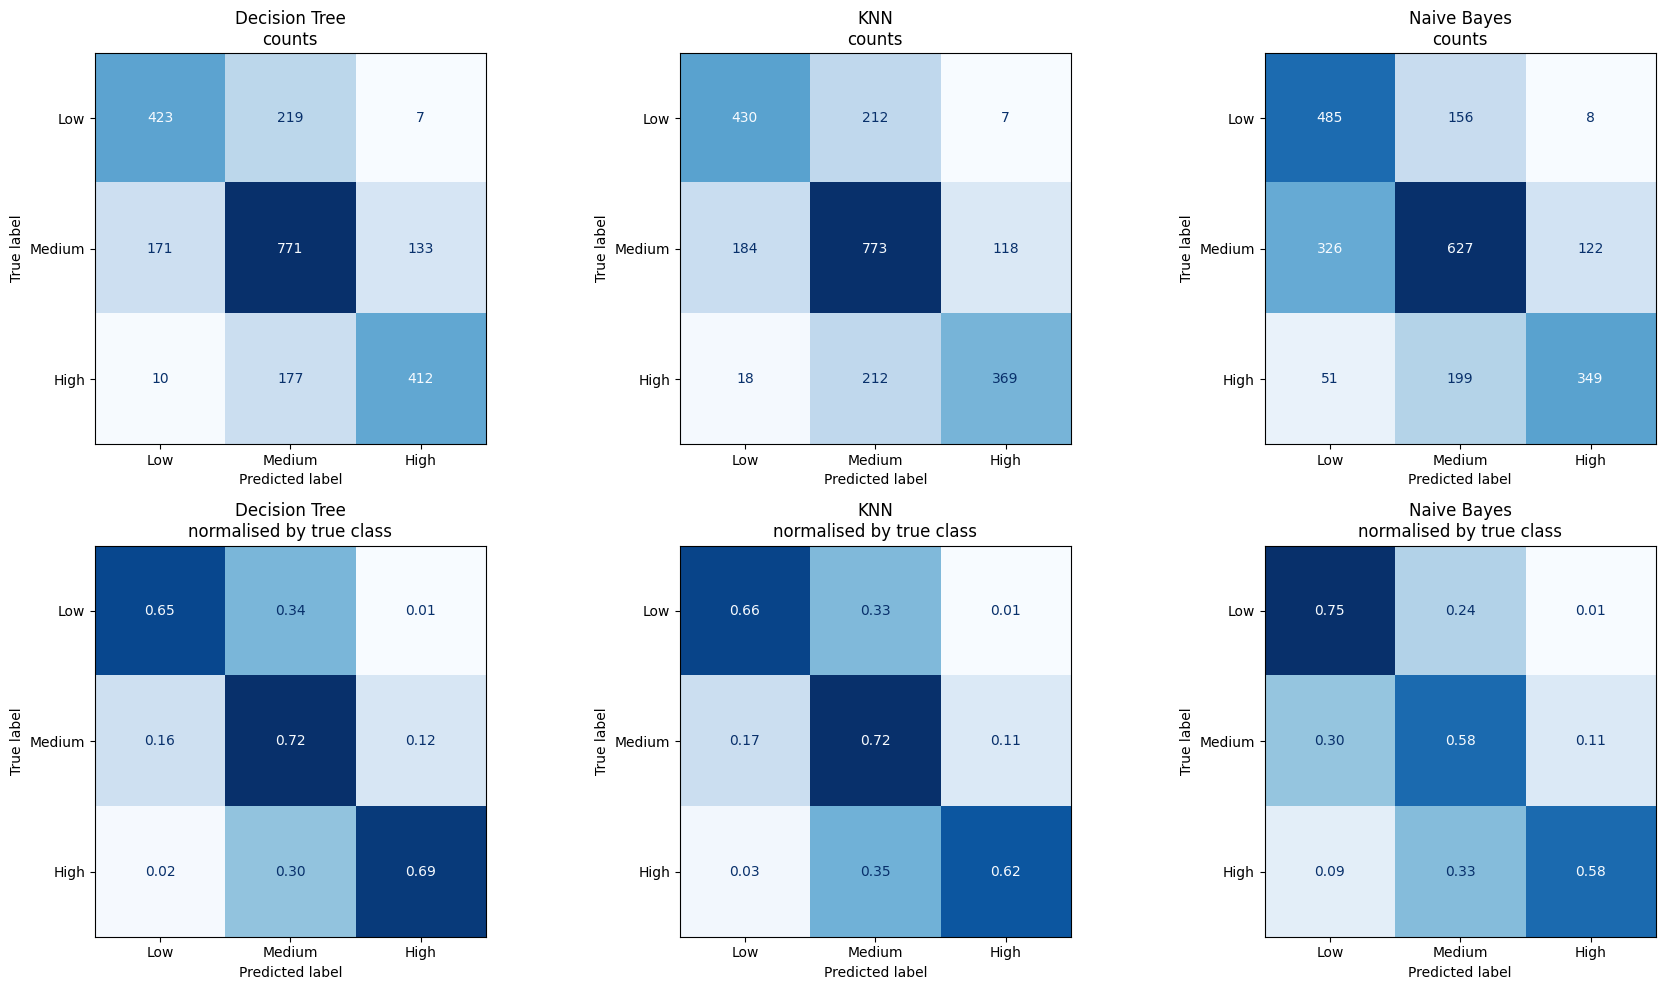

Error structure (validation set):
  Decision Tree   correct  69.1%  |  adjacent  30.1%  |  Low<->High   0.7%
  KNN             correct  67.7%  |  adjacent  31.3%  |  Low<->High   1.1%
  Naive Bayes     correct  62.9%  |  adjacent  34.6%  |  Low<->High   2.5%


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for j, (name, (m, f)) in enumerate(models.items()):
    y_pred = m.predict(X_val[f])
    for i, (norm, fmt, cmap) in enumerate([(None, "d", "Blues"), ("true", ".2f", "Blues")]):
        cm = confusion_matrix(y_val, y_pred, labels=[0, 1, 2], normalize=norm)
        ConfusionMatrixDisplay(cm, display_labels=CLASS_ORDER).plot(
            ax=axes[i, j], cmap=cmap, colorbar=False, values_format=fmt)
        axes[i, j].set_title(f"{name}\n{'counts' if norm is None else 'normalised by true class'}")
        axes[i, j].grid(False)

plt.tight_layout()
plt.savefig(f'{REPORTS}/confusion_matrices_val.png', dpi=150, bbox_inches="tight")
plt.show()

# Adjacent vs distant errors — Rating is ordinal, so Low -> High is worse than Low -> Medium
print("Error structure (validation set):")
for name, (m, f) in models.items():
    y_pred = m.predict(X_val[f])
    d = np.abs(y_pred - y_val)
    print(f"  {name:15s} correct {(d==0).mean()*100:5.1f}%  |  "
          f"adjacent {(d==1).mean()*100:5.1f}%  |  Low<->High {(d==2).mean()*100:5.1f}%")

### Confusion matrices and error structure

The matrices are shown twice: as raw counts, and normalised by true class, where
the diagonal gives per-class recall. Classes are ordered Low → Medium → High so
that confusions between adjacent rating levels appear next to the diagonal.

All three models share a common pattern. Medium is recovered best by the Decision
Tree and KNN (recall 0.72), while the flanking classes are harder — Low at 0.65
and High at 0.69 for the tree. This is expected: Medium occupies the centre of a
continuum and absorbs the ambiguous cases, while Low and High are defined by
being far from it, so games near the boundaries are pulled inward.

**Because `Rating` is ordinal, the distance of an error matters as much as its
frequency.** Misclassifying a Low game as Medium is a small miss; calling it High
is a complete failure. The error distribution separates these:

| Model | Correct | Adjacent error | Low ↔ High |
|---|---|---|---|
| Decision Tree | 69.1% | 30.1% | **0.7%** |
| KNN | 67.7% | 31.3% | 1.1% |
| Naive Bayes | 62.9% | 34.6% | 2.5% |

The Decision Tree confuses the two extreme classes in 0.7% of cases — 17 games
out of 2,323. Essentially every error it makes is a one-step displacement along
the rating scale. An accuracy of 0.691 reads as unremarkable in isolation, but
combined with a 0.7% severe-error rate it describes a model that reliably places
games in the right region of the scale and occasionally disagrees about which
side of a boundary they fall on. For a target derived by discretising a
continuous average rating, boundary disagreement is close to irreducible: games
near a cut point are genuinely ambiguous, and no model can resolve a distinction
the data does not contain.

The severe-error rates order the models identically to their aggregate scores
(0.7%, 1.1%, 2.5%) — gross errors are not uniform noise but track model quality,
and Naive Bayes makes them more than three times as often as the tree.

Its bias is visible directly in the matrices. Of 1,075 Medium games it assigns
326 to Low, against 171 for the Decision Tree — nearly double. Its Low recall of
0.75 is the highest of any model on any class, but it is bought by pulling
mid-rated games down rather than by identifying low-rated ones more accurately,
which is why its Low precision is the worst at 0.56.

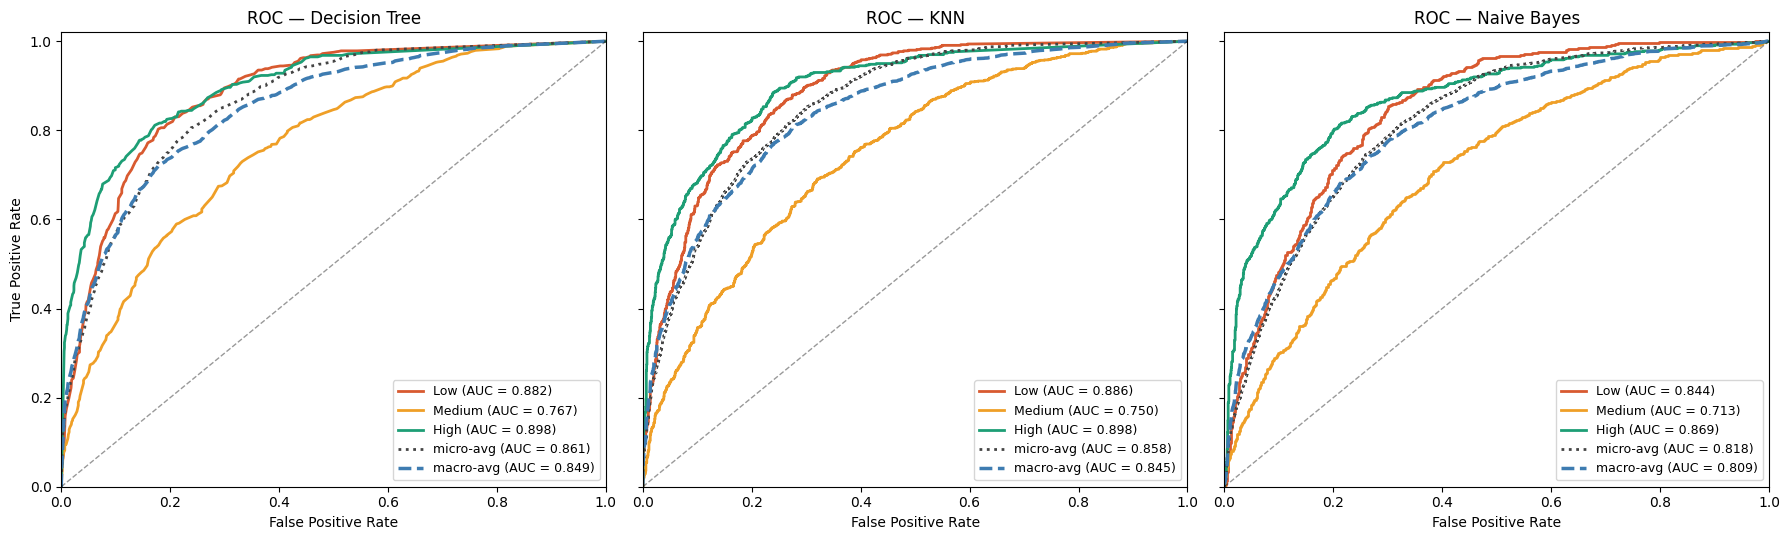

                  Low  Medium    High   micro   macro
Decision Tree  0.8823  0.7666  0.8976  0.8615  0.8489
KNN            0.8855  0.7496  0.8980  0.8579  0.8447
Naive Bayes    0.8443  0.7128  0.8688  0.8178  0.8090


In [ ]:
y_val_bin = label_binarize(y_val, classes=[0, 1, 2])
colors = {"Low": "#D85A30", "Medium": "#EF9F27", "High": "#1D9E75"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)
auc_table = {}

for ax, (name, (m, f)) in zip(axes, models.items()):
    y_score = m.predict_proba(X_val[f])
    fpr, tpr, roc_auc = {}, {}, {}

    for i, cls in enumerate(CLASS_ORDER):
        fpr[cls], tpr[cls], _ = roc_curve(y_val_bin[:, i], y_score[:, i])
        roc_auc[cls] = auc(fpr[cls], tpr[cls])
        ax.plot(fpr[cls], tpr[cls], color=colors[cls], lw=2,
                label=f"{cls} (AUC = {roc_auc[cls]:.3f})")

    # micro-average: all one-vs-rest decisions flattened into one binary problem
    fpr_mi, tpr_mi, _ = roc_curve(y_val_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr_mi, tpr_mi)
    ax.plot(fpr_mi, tpr_mi, color="#444444", lw=2, ls=":",
            label=f"micro-avg (AUC = {roc_auc['micro']:.3f})")

    # macro-average: per-class curves interpolated onto a common FPR grid
    all_fpr = np.unique(np.concatenate([fpr[c] for c in CLASS_ORDER]))
    mean_tpr = np.mean([np.interp(all_fpr, fpr[c], tpr[c]) for c in CLASS_ORDER], axis=0)
    roc_auc["macro"] = auc(all_fpr, mean_tpr)
    ax.plot(all_fpr, mean_tpr, color="#3E7CB1", lw=2.5, ls="--",
            label=f"macro-avg (AUC = {roc_auc['macro']:.3f})")

    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.set_xlabel("False Positive Rate")
    ax.set_title(f"ROC — {name}")
    ax.legend(loc="lower right", fontsize=9)
    auc_table[name] = roc_auc

axes[0].set_ylabel("True Positive Rate")
plt.tight_layout()
plt.savefig(f'{REPORTS}/roc_curves_val.png', dpi=150, bbox_inches="tight")
plt.show()

print(pd.DataFrame(auc_table).T[CLASS_ORDER + ["micro", "macro"]].round(4))

### ROC curves

With three classes the ROC analysis uses a One-vs-Rest decomposition: each class
against the other two, giving three curves per model, plus two aggregates.
Micro-averaging pools all one-vs-rest decisions into a single binary problem and
therefore weights each observation equally, so the larger Medium class dominates.
Macro-averaging interpolates the three curves onto a common false-positive grid
and averages them, weighting each class equally. Macro-AUC is the figure quoted
in the model comparison, for consistency with macro-F1 as the selection metric.

| Model | Low | Medium | High | micro | macro |
|---|---|---|---|---|---|
| Decision Tree | 0.882 | **0.767** | 0.898 | 0.862 | **0.849** |
| KNN | **0.886** | 0.750 | **0.898** | 0.858 | 0.845 |
| Naive Bayes | 0.844 | 0.713 | 0.869 | 0.818 | 0.809 |

**The Medium class is the hardest to separate in every model**, by a wide margin:
0.767 against 0.898 for High in the Decision Tree, a gap of 0.13. The curves make
this visible — the orange Medium curve sits well below the other two throughout
its range.

The reason is structural rather than a deficiency of any algorithm. `Rating` is a
discretisation of a continuous average score, and Medium is the interval in the
middle. A one-vs-rest classifier for Medium must therefore identify games that
are *neither* low nor high, which requires locating two boundaries rather than
one, and the class has no distinguishing property of its own — it is defined by
the absence of the extremes. Low and High occupy the tails, where the separating
signal is strong and one-sided.

**The aggregate ranking conceals a reversal.** KNN outperforms the Decision Tree
on Low (0.886 against 0.882) and matches it exactly on High (0.898). The tree's
overall advantage rests entirely on the Medium class, where it leads by 0.017.
The two models are equivalent at ranking games in the tails and differ only in
how well they handle the ambiguous middle — which is consistent with the
confusion matrices, where their Low and High recalls are close while the tree
recovers more of the Medium class.

Naive Bayes trails on all three classes but by an unremarkable margin: its macro
AUC of 0.809 is only 0.04 below the tree, against a macro-F1 gap of 0.06. Its
probability ranking is respectable; the deficit lies in where it places the
decision thresholds, as the class-assignment bias identified earlier predicts.

All curves lie well above the diagonal, so all three models carry substantial
signal. An AUC near 0.85 means that for a randomly chosen pair of games from
different classes, the model assigns the higher probability to the correct one
roughly 85% of the time.

FINAL MODEL: Decision Tree

              precision    recall  f1-score   support

         Low       0.71      0.68      0.69       650
      Medium       0.67      0.73      0.70      1075
        High       0.75      0.67      0.71       599

    accuracy                           0.70      2324
   macro avg       0.71      0.69      0.70      2324
weighted avg       0.70      0.70      0.70      2324

Validation vs test — checking for overfitting to the selection process:
                      validation    test  difference
Accuracy                  0.6913  0.6988      0.0074
Precision (macro)         0.7025  0.7113      0.0088
Recall (macro)            0.6856  0.6919      0.0063
F1 (macro)                0.6930  0.7002      0.0072
F1 (weighted)             0.6915  0.6990      0.0075
ROC-AUC (macro, OvR)      0.8488  0.8546      0.0057

Error structure on test: correct 69.9%  |  adjacent 29.5%  |  Low<->High 0.6%


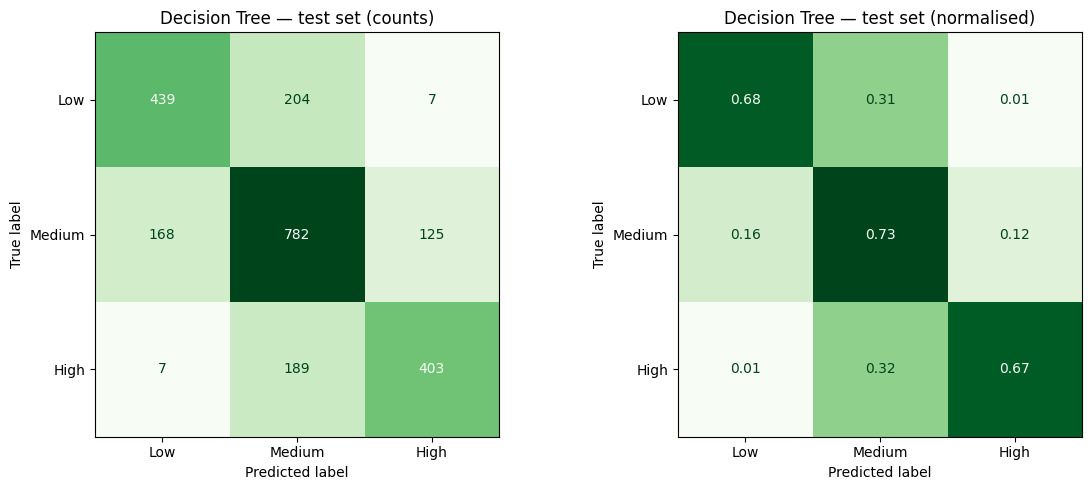

In [ ]:
print(f"FINAL MODEL: {BEST_NAME}\n")

y_pred_test = best_model.predict(X_test[best_feats])
print(classification_report(y_test, y_pred_test, target_names=CLASS_ORDER, zero_division=0))

print("Validation vs test — checking for overfitting to the selection process:")
comparison = pd.DataFrame({
    "validation": evaluate(best_model, best_feats, X_val,  y_val),
    "test":       evaluate(best_model, best_feats, X_test, y_test),
})
comparison["difference"] = comparison["test"] - comparison["validation"]
print(comparison.round(4))

d = np.abs(y_pred_test - y_test)
print(f"\nError structure on test: correct {(d==0).mean()*100:.1f}%  |  "
      f"adjacent {(d==1).mean()*100:.1f}%  |  Low<->High {(d==2).mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, norm, fmt in zip(axes, [None, "true"], ["d", ".2f"]):
    cm = confusion_matrix(y_test, y_pred_test, labels=[0, 1, 2], normalize=norm)
    ConfusionMatrixDisplay(cm, display_labels=CLASS_ORDER).plot(
        ax=ax, cmap="Greens", colorbar=False, values_format=fmt)
    ax.set_title(f"{BEST_NAME} — test set ({'counts' if norm is None else 'normalised'})")
    ax.grid(False)
plt.tight_layout()
plt.savefig(f'{REPORTS}/confusion_matrix_test_best.png', dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
y_dummy = dummy.predict(X_test)
print("Majority-class baseline — accuracy:", round(accuracy_score(y_test, y_dummy), 4),
      "| macro-F1:", round(f1_score(y_test, y_dummy, average="macro"), 4))

Majority-class baseline — accuracy: 0.4626 | macro-F1: 0.2108


### Final evaluation on the held-out test set

The Decision Tree was applied once to the test set, which took no part in
hyperparameter tuning or in the comparison between algorithms.

| Metric | Validation | Test | Difference |
|---|---|---|---|
| Accuracy | 0.691 | 0.699 | +0.007 |
| Precision (macro) | 0.703 | 0.711 | +0.009 |
| Recall (macro) | 0.686 | 0.692 | +0.006 |
| F1 (macro) | 0.693 | **0.700** | +0.007 |
| F1 (weighted) | 0.692 | 0.699 | +0.008 |
| ROC-AUC (macro) | 0.849 | 0.855 | +0.006 |

Test performance slightly exceeds validation performance on all six metrics, by
0.006 to 0.009. The direction matters more than the magnitude. Had the test
figures fallen materially below the validation ones, the model selection
procedure would itself have overfitted — 96 tree configurations, 28 KNN
configurations and twelve smoothing values were compared, and the winner of that
many comparisons is partly a winner by chance. The absence of any such drop
indicates that the selection generalises; the small positive difference is
ordinary sampling variation across two independent samples of roughly 2,300 games.

Per-class performance on the test set: Low F1 0.69, Medium 0.70, High 0.71 —
balanced across all three, with no class systematically disadvantaged.

The error structure holds: 69.9% correct, 29.5% off by one rating level, and
**0.6% confusing Low with High** — 14 games out of 2,324. The model reliably
places games in the correct region of the rating scale, and where it errs it errs
by a single step.

**Final reported performance: macro-F1 0.700, accuracy 0.699, macro ROC-AUC
0.855.** For context, the majority-class baseline achieves 0.463 accuracy, macro-F1 0.211, and the model improvement is +0.236 accuracy and +0.489 macro-F1.

Depth: 10  |  Leaves: 295

Feature importances:
NumWant_log           0.4127
YearPublished         0.2266
ComWeight             0.1823
NumUserRatings_log    0.0508
Cat:War               0.0409
MaxPlayers            0.0208
ComAgeRec             0.0201
MfgPlaytime_log       0.0174
NumExpansions         0.0138
MinPlayers            0.0039
Cat:Strategy          0.0032
Cat:Family            0.0023
IsReimplementation    0.0020
Kickstarted           0.0017
Cat:Thematic          0.0016
dtype: float64
Unused features: 5 of 20


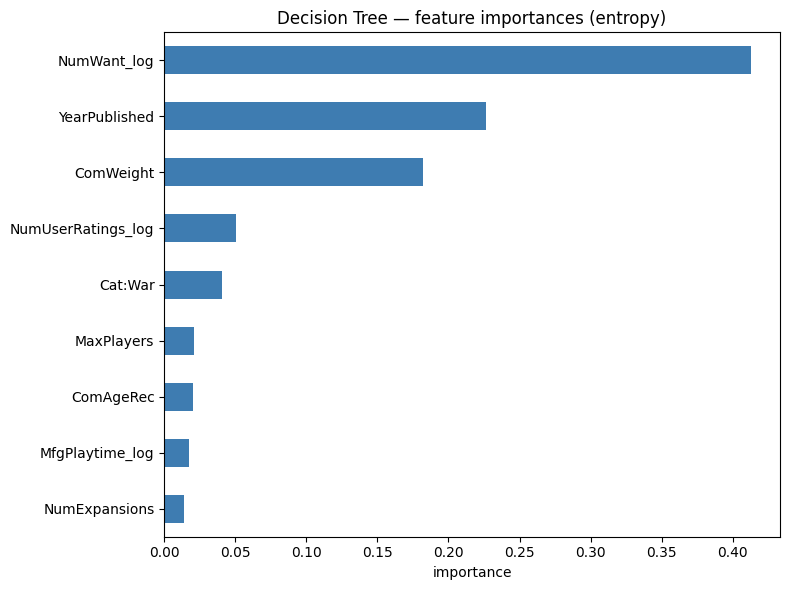

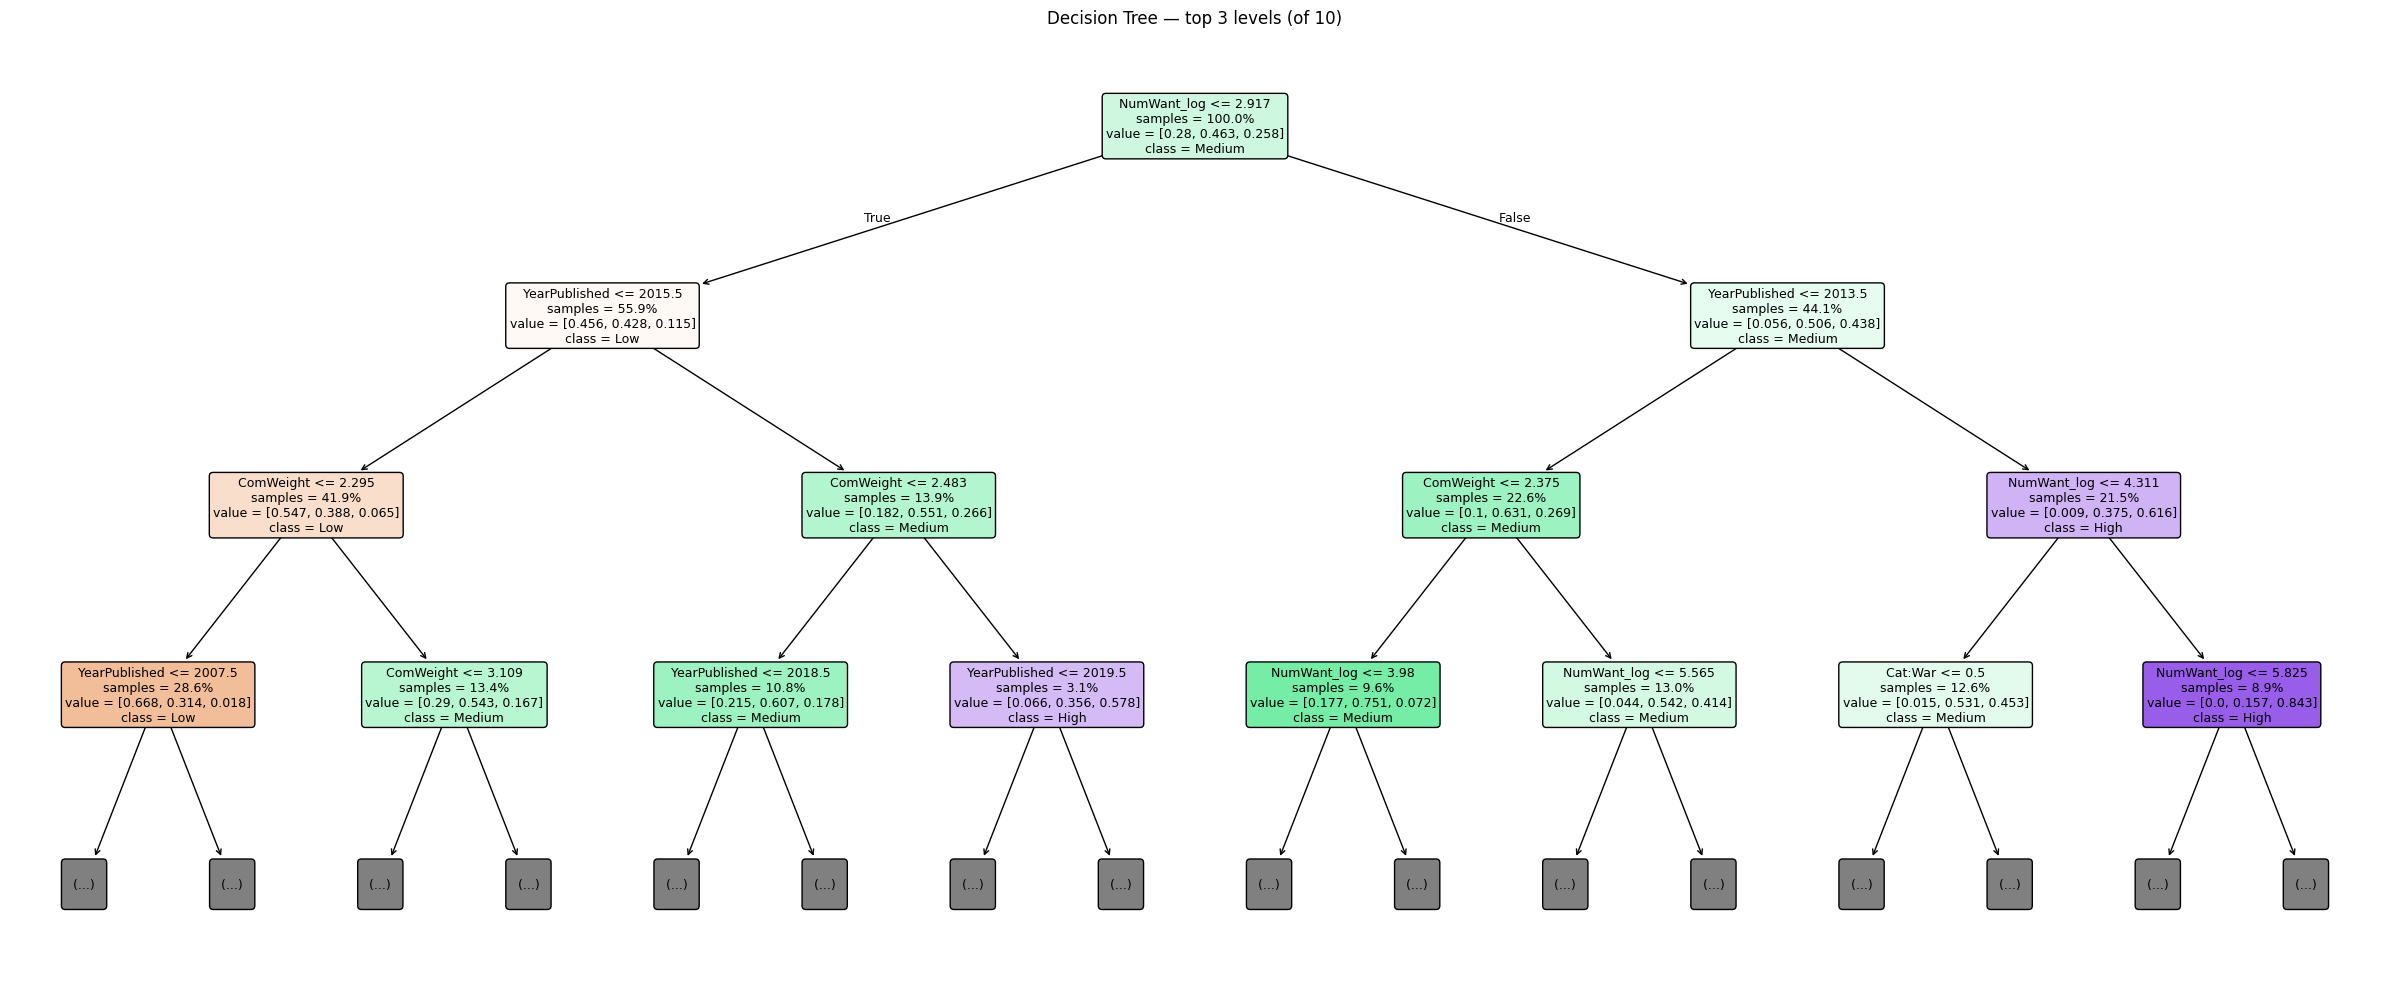

In [ ]:
dt_final = best_model.named_steps["clf"]

print(f"Depth: {dt_final.get_depth()}  |  Leaves: {dt_final.get_n_leaves()}")

imp = (pd.Series(dt_final.feature_importances_, index=classification_features)
         .sort_values(ascending=False))
print("\nFeature importances:")
print(imp[imp > 0].round(4))
print(f"Unused features: {(imp == 0).sum()} of {len(imp)}")

fig, ax = plt.subplots(figsize=(8, 6))
imp[imp > 0.005].iloc[::-1].plot(kind="barh", ax=ax, color="#3E7CB1")
ax.set_title("Decision Tree — feature importances (entropy)")
ax.set_xlabel("importance")
plt.tight_layout()
plt.savefig(f'{REPORTS}/dt_feature_importances.png', dpi=150, bbox_inches="tight")
plt.show()

# Top levels only — a depth-10 tree has too many nodes to render legibly
plt.figure(figsize=(24, 10))
plot_tree(dt_final, max_depth=3, feature_names=classification_features,
          class_names=CLASS_ORDER, filled=True, rounded=True,
          fontsize=9, impurity=False, proportion=True)
plt.title("Decision Tree — top 3 levels (of 10)")
plt.tight_layout()
plt.savefig(f'{REPORTS}/decision_tree_top3.png', dpi=150, bbox_inches="tight")
plt.show()

### Interpreting the tree

The final tree has depth 10 and 295 leaves. Fifteen of the twenty features are
used at least once, but importance is heavily concentrated: `NumWant_log` (0.413),
`YearPublished` (0.227) and `ComWeight` (0.182) account for 82% of the total, and
nine features together contribute under 2%.

The top three levels are almost entirely built from these three variables, and
the structure is directly readable.

**Root split: `NumWant_log ≤ 2.917`** — roughly 18 wishlist entries. This single
cut divides the dataset into 55.9% and 44.1% and reorients the class
distribution completely. Below the threshold the mixture is [0.456, 0.428, 0.115]
— High almost disappears. Above it the mixture is [0.056, 0.506, 0.438] — Low
almost disappears. Demand alone comes close to excluding one extreme class or the
other before any other attribute is consulted.

**Second level: `YearPublished` on both branches**, at 2015.5 on the
low-demand side and 2013.5 on the high-demand side. The tree spends its second
question on recency regardless of which branch it is in, confirming what the
Module 1 boxplots suggested — publication year is not a marginal covariate but
one of the primary axes along which ratings separate.

**Third level: `ComWeight`** at thresholds of 2.295, 2.375 and 2.483 across three
of the four branches. Complexity enters last of the three and its cut points are
remarkably consistent, all falling near 2.3–2.5 on the 1–5 scale. The tree has
located a stable boundary between "light" and "substantial" games and applies it
in whichever context it arrives at.

The decision logic therefore reads as a three-question sequence: *how many people
want it, how recent is it, how demanding is it.* Two illustrative paths through
the tree:

- Low demand, published before 2007.5 → 28.6% of games, distribution
  [0.668, 0.314, 0.018]. Older games that nobody is seeking out are Low-rated
  two times out of three, and High-rated in under 2% of cases.
- High demand (`NumWant_log > 4.311`, roughly 74 wishlist entries), published
  after 2013.5 → 8.9% of games, distribution [0.0, 0.157, 0.843]. Not a single
  game in this region is Low-rated, and 84% are High.

`Cat:War` is the only category flag with appreciable importance (0.041), and it
appears at level three within the high-demand recent branch, where the
distribution is nearly balanced between Medium and High ([0.015, 0.531, 0.453]).
Wargames form the one genre with a rating profile distinct enough to be worth a
split; the remaining seven category flags contribute 0.007 combined. This is
consistent with the Module 1 finding that game category carries far less
information about ratings than complexity, recency or demand.

Five features are never used: `NumWant_log` and the two other strong predictors
render them redundant rather than uninformative — `NumOwned_log` was already
excluded for correlating at 0.95 with `NumUserRatings_log`, and the same
redundancy logic operates inside the tree, where a feature correlated with one
already split on adds nothing at that node.

**A caveat on importance.** Impurity-based importance measures how much each
feature reduces entropy at the splits where it is chosen, conditional on the
splits already made. It is not a measure of standalone predictive strength.
`ComWeight` correlates with the target at 0.489 against `NumUserRatings_log`'s
0.286, yet receives 0.182 importance against 0.051 — the ordering is preserved
here, but the magnitudes are not comparable across correlated features. A feature
entering the tree after a correlated one will always appear weaker than it is in
isolation.

## 2. Regression

### Choice of target and predictors

`ComWeight` is used as the regression target. It is continuous, bounded on a
1–5 scale, and free of the extreme skew that affects the count variables, so it
requires no transformation. Substantively it answers an interpretable question —
what makes a board game demanding — and the answer is meaningful to a non-specialist.

The choice also avoids a methodological trap. Taking a popularity variable as the
target while using other popularity variables as predictors would produce a high
R² for an uninformative reason: the Module 1 correlation analysis established that
`NumOwned_log`, `NumUserRatings_log`, `NumWant_log`, `NumWish_log` and
`NumWeightVotes_log` correlate at 0.70–0.95 because they all count the same
underlying phenomenon. A model predicting one from the others would be measuring
its own inputs. `ComWeight` belongs to a different dimension, so its predictors
have to carry genuinely separate information.

One caution follows from Module 1: 506 games carried `ComWeight = 0` as a
"nobody voted" sentinel rather than a measured value, all with
`NumWeightVotes = 0`. These are treated as missing and excluded here. Had they
been retained, 506 artificial zeros at the bottom of the scale would have biased
every model towards a shallower slope.

**Simple regression** uses `MfgPlaytime_log` as the single predictor. It
correlates with `ComWeight` at r = 0.72 — the strongest relationship in the
dataset between two conceptually independent variables, and stronger than
`ComAgeRec` at 0.66. This choice is itself a product of the data cleaning: on the
uncorrected data the same pair correlated at only 0.18, the relationship obscured
by the 780 records where `MfgPlaytime = 0` encoded "not specified" and `log1p`
mapped that sentinel onto a plausible-looking value. Longer games are more
complex, and the strength of that relationship only became visible after the
sentinel was treated.

**Multiple regression** adds `ComAgeRec`, `MinPlayers`, `MaxPlayers`,
`NumExpansions` and `YearPublished`, and is solved with one linear and two
non-linear approaches.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

REG_TARGET = "ComWeight"
REG_SIMPLE = ["MfgPlaytime_log"]
REG_MULTI  = ["MfgPlaytime_log", "ComAgeRec", "MinPlayers", "MaxPlayers",
              "NumExpansions", "YearPublished"]

df_reg = data_clean[REG_MULTI + [REG_TARGET]].dropna()
print("Shape:", df_reg.shape)
print(f"Rows lost: {len(data_clean) - len(df_reg)} "
      f"({(1 - len(df_reg)/len(data_clean))*100:.1f}%)")

print("\nTarget distribution:")
print(df_reg[REG_TARGET].describe().round(3))

print("\nCorrelation with the target:")
print(df_reg[REG_MULTI].corrwith(df_reg[REG_TARGET]).sort_values(key=abs, ascending=False).round(3))

Xr = df_reg[REG_MULTI]
yr = df_reg[REG_TARGET]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=42)
print(f"\nTrain: {len(Xr_train)}  Test: {len(Xr_test)}")

Shape: (15487, 7)
Rows lost: 5694 (26.9%)

Target distribution:
count    15487.000
mean         2.283
std          0.809
min          1.100
25%          1.606
50%          2.195
75%          2.817
max          5.213
Name: ComWeight, dtype: float64

Correlation with the target:
MfgPlaytime_log    0.738
ComAgeRec          0.659
MaxPlayers        -0.253
MinPlayers        -0.182
NumExpansions      0.139
YearPublished     -0.009
dtype: float64

Train: 12389  Test: 3098


Model: ComWeight = -0.2665 + 0.6419 * MfgPlaytime_log

R²   : 0.5519
MSE  : 0.2957
RMSE : 0.5438
MAE  : 0.4234


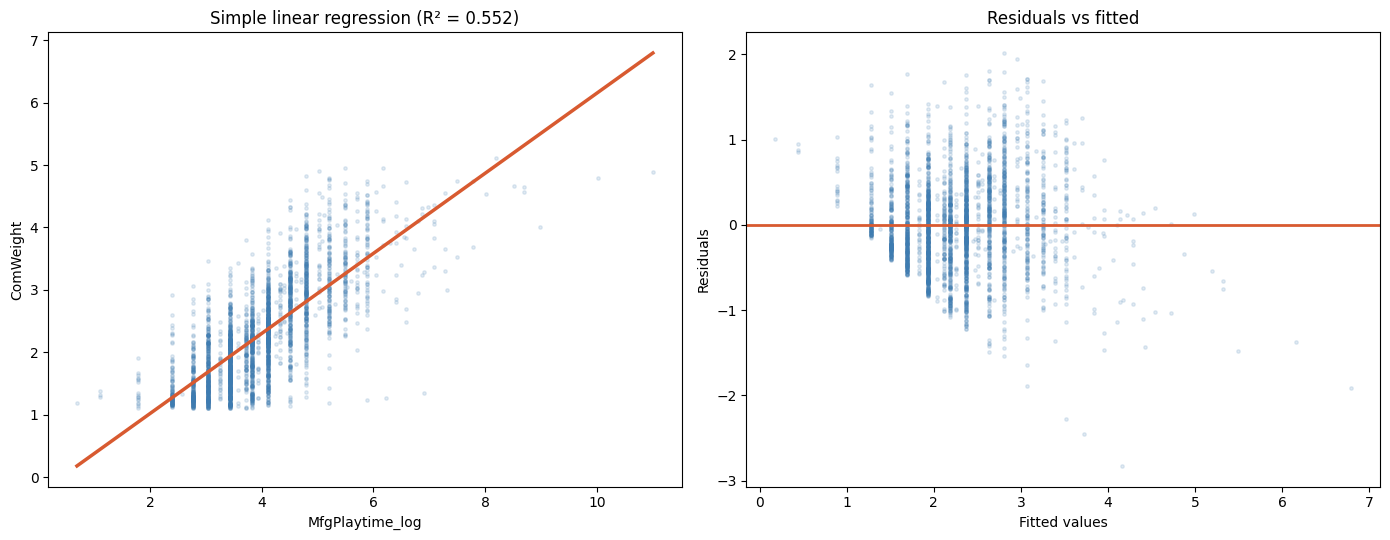

In [ ]:
Xs_train = Xr_train[REG_SIMPLE]
Xs_test  = Xr_test[REG_SIMPLE]

lin_simple = LinearRegression().fit(Xs_train, yr_train)
y_pred_s = lin_simple.predict(Xs_test)

print(f"Model: ComWeight = {lin_simple.intercept_:.4f} + "
      f"{lin_simple.coef_[0]:.4f} * MfgPlaytime_log\n")
print(f"R²   : {r2_score(yr_test, y_pred_s):.4f}")
print(f"MSE  : {mean_squared_error(yr_test, y_pred_s):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(yr_test, y_pred_s)):.4f}")
print(f"MAE  : {mean_absolute_error(yr_test, y_pred_s):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Scatter with the fitted line
axes[0].scatter(Xs_test, yr_test, s=6, alpha=0.15, color="#3E7CB1")
grid = pd.DataFrame({"MfgPlaytime_log": np.linspace(
    Xs_test.values.min(), Xs_test.values.max(), 100)})
axes[0].plot(grid, lin_simple.predict(grid), color="#D85A30", lw=2.5)
axes[0].set_xlabel("MfgPlaytime_log"); axes[0].set_ylabel("ComWeight")
axes[0].set_title(f"Simple linear regression (R² = {r2_score(yr_test, y_pred_s):.3f})")

# Residuals against fitted values — checks the linearity and homoscedasticity assumptions
resid = yr_test - y_pred_s
axes[1].scatter(y_pred_s, resid, s=6, alpha=0.15, color="#3E7CB1")
axes[1].axhline(0, color="#D85A30", lw=2)
axes[1].set_xlabel("Fitted values"); axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs fitted")

plt.tight_layout()
plt.savefig(f'{REPORTS}/regression_simple.png', dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# How often does a linear model predict outside the scale?
print(f"Predictions above the observed maximum ({yr.max():.2f}): "
      f"{(y_pred_s > yr.max()).sum()} of {len(y_pred_s)}")
print(f"Predictions below the observed minimum ({yr.min():.2f}): "
      f"{(y_pred_s < yr.min()).sum()}")

# Error by region of the fitted range
bins = pd.cut(y_pred_s, [0, 2, 3, 4, 10], labels=["<2", "2-3", "3-4", ">4"])
print("\nMean residual and RMSE by fitted range:")
print(pd.DataFrame({"resid_mean": resid, "abs_resid": np.abs(resid), "bin": bins})
        .groupby("bin", observed=True)
        .agg(n=("resid_mean", "size"), mean_residual=("resid_mean", "mean"),
             mae=("abs_resid", "mean")).round(3))

Predictions above the observed maximum (5.21): 5 of 3098
Predictions below the observed minimum (1.10): 21

Mean residual and RMSE by fitted range:
        n  mean_residual    mae
bin                            
<2   1190         -0.025  0.355
2-3  1543          0.011  0.448
3-4   335          0.083  0.528
>4     30         -0.648  0.709


### Simple linear regression

`ComWeight = -0.267 + 0.642 × MfgPlaytime_log`

| Metric | Value |
|---|---|
| R² | 0.552 |
| MSE | 0.296 |
| RMSE | 0.544 |
| MAE | 0.423 |

A single predictor explains 55% of the variance in game complexity. The
coefficient means that each unit increase in log-playtime — a factor of e ≈ 2.7
in minutes — corresponds to 0.64 additional points of complexity on the 1–5
scale. Doubling a game's length raises its expected complexity by about 0.44
points. Given that the target has a standard deviation of 0.809, an RMSE of 0.544
represents a substantial reduction in uncertainty.

The relationship itself only became measurable after the data preparation of
Module 1. On the uncorrected data `ComWeight` and `MfgPlaytime_log` correlated at
0.18; treating the 780 `MfgPlaytime = 0` sentinels as missing raised this to
0.738 on the regression subset. A model fitted before that correction would have
explained roughly 3% of the variance instead of 55%.

**Diagnostics.** The residual plot shows three features worth reporting.

The vertical banding in both plots reflects the discreteness of `MfgPlaytime`,
which clusters on conventional values (30, 45, 60, 90, 120 minutes). This is a
property of the data rather than a modelling problem.

Error grows with the fitted value, and the growth is not symmetric:

| Fitted range | n | Mean residual | MAE |
|---|---|---|---|
| < 2 | 1,190 | -0.025 | 0.355 |
| 2–3 | 1,543 | +0.011 | 0.448 |
| 3–4 | 335 | +0.083 | 0.528 |
| > 4 | 30 | **-0.648** | 0.709 |

Across the range covering 88% of games the model is close to unbiased, with mean
residuals within ±0.03. In the sparse upper tail it over-predicts systematically:
for the 30 games with fitted values above 4, actual complexity averages 0.65
points below the prediction. The linear form extrapolates a constant slope into a
region where the true relationship flattens — the longest games are not
proportionally more complex, since multi-day wargames owe much of their duration
to scale rather than to rules difficulty.

A related consequence: the model produces predictions outside the observed range
of the target in 26 of 3,098 cases (0.8%) — five above the maximum of 5.21 and 21
below the minimum of 1.10. Linear regression has no knowledge of the scale
boundaries, so a bounded target will always admit some impossible predictions.

Neither issue invalidates the model at 88% of the data, but both point in the
same direction: the relationship is close to linear in the body of the
distribution and flattens at the top. This motivates the non-linear approaches
compared in the multiple regression below, which fit piecewise-constant
predictions and therefore cannot extrapolate beyond the observed target range by
construction.

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

reg_models = {}

# --- Linear -----------------------------------------------------------------
reg_models["Linear Regression"] = LinearRegression().fit(Xr_train, yr_train)

# --- Random Forest ----------------------------------------------------------
rf_grid = {
    "n_estimators":      [200],
    "max_depth":         [10, 15, 20, None],
    "min_samples_leaf":  [1, 5, 20],
}
rf_search = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                         rf_grid, scoring="r2", cv=5, n_jobs=-1).fit(Xr_train, yr_train)
reg_models["Random Forest"] = rf_search.best_estimator_
print("RF  best:", rf_search.best_params_, "| CV R²:", round(rf_search.best_score_, 4))

# --- Gradient Boosting ------------------------------------------------------
gb_grid = {
    "n_estimators":  [200, 400],
    "learning_rate": [0.05, 0.1],
    "max_depth":     [3, 5],
}
gb_search = GridSearchCV(GradientBoostingRegressor(random_state=42),
                         gb_grid, scoring="r2", cv=5, n_jobs=-1).fit(Xr_train, yr_train)
reg_models["Gradient Boosting"] = gb_search.best_estimator_
print("GB  best:", gb_search.best_params_, "| CV R²:", round(gb_search.best_score_, 4))

# --- Comparison -------------------------------------------------------------
rows = {}
for name, m in reg_models.items():
    pred = m.predict(Xr_test)
    rows[name] = {
        "R²":   r2_score(yr_test, pred),
        "MSE":  mean_squared_error(yr_test, pred),
        "RMSE": np.sqrt(mean_squared_error(yr_test, pred)),
        "MAE":  mean_absolute_error(yr_test, pred),
        "outside scale": int(((pred > yr.max()) | (pred < yr.min())).sum()),
    }

# Simple regression as the reference point
rows["Simple (1 predictor)"] = {
    "R²": r2_score(yr_test, y_pred_s),
    "MSE": mean_squared_error(yr_test, y_pred_s),
    "RMSE": np.sqrt(mean_squared_error(yr_test, y_pred_s)),
    "MAE": mean_absolute_error(yr_test, y_pred_s),
    "outside scale": int(((y_pred_s > yr.max()) | (y_pred_s < yr.min())).sum()),
}

reg_results = pd.DataFrame(rows).T
print("\nTest set:")
print(reg_results.round(4))

RF  best: {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 200} | CV R²: 0.7097
GB  best: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200} | CV R²: 0.7131

Test set:
                          R²     MSE    RMSE     MAE  outside scale
Linear Regression     0.6383  0.2387  0.4886  0.3717           47.0
Random Forest         0.7105  0.1911  0.4371  0.3324            0.0
Gradient Boosting     0.7150  0.1881  0.4337  0.3281            1.0
Simple (1 predictor)  0.5519  0.2957  0.5438  0.4234           26.0


In [ ]:
gb_best = reg_models["Gradient Boosting"]
rf_best = reg_models["Random Forest"]

imp_reg = pd.DataFrame({
    "Random Forest":     rf_best.feature_importances_,
    "Gradient Boosting": gb_best.feature_importances_,
}, index=REG_MULTI).sort_values("Gradient Boosting", ascending=False)

# Linear coefficients on standardised features, for comparability
from sklearn.pipeline import make_pipeline
lin_std = make_pipeline(StandardScaler(), LinearRegression()).fit(Xr_train, yr_train)
imp_reg["Linear (std. coef)"] = pd.Series(
    lin_std.named_steps["linearregression"].coef_, index=REG_MULTI)

print(imp_reg.round(4))

# Does the tail bias of the linear model disappear?
pred_gb = gb_best.predict(Xr_test)
resid_gb = yr_test - pred_gb
bins_gb = pd.cut(pred_gb, [0, 2, 3, 4, 10], labels=["<2", "2-3", "3-4", ">4"])
print("\nGradient Boosting — residuals by fitted range:")
print(pd.DataFrame({"r": resid_gb, "ar": np.abs(resid_gb), "bin": bins_gb})
        .groupby("bin", observed=True)
        .agg(n=("r", "size"), mean_residual=("r", "mean"), mae=("ar", "mean")).round(3))

                 Random Forest  Gradient Boosting  Linear (std. coef)
MfgPlaytime_log         0.6349             0.6453              0.4168
ComAgeRec               0.2284             0.2300              0.2477
MaxPlayers              0.0639             0.0675             -0.1108
NumExpansions           0.0270             0.0265              0.0634
YearPublished           0.0368             0.0211              0.0490
MinPlayers              0.0090             0.0097             -0.0455

Gradient Boosting — residuals by fitted range:
        n  mean_residual    mae
bin                            
<2   1281          0.008  0.272
2-3  1290         -0.015  0.341
3-4   510          0.062  0.434
>4     17          0.279  0.410


### Multiple regression

Six predictors, three approaches. Random Forest and Gradient Boosting were tuned
by 5-fold cross-validated R² (RF: 12 configurations, best at max_depth=10,
min_samples_leaf=5; GB: 8 configurations, best at learning_rate=0.05,
max_depth=5, n_estimators=200).

| Model | R² | MSE | RMSE | MAE | Predictions outside scale |
|---|---|---|---|---|---|
| Simple linear (1 predictor) | 0.552 | 0.296 | 0.544 | 0.423 | 26 |
| Linear Regression | 0.638 | 0.239 | 0.489 | 0.372 | 47 |
| Random Forest | 0.711 | 0.191 | 0.437 | 0.332 | **0** |
| **Gradient Boosting** | **0.715** | **0.188** | **0.434** | **0.328** | 1 |

Adding five predictors to the linear model raises R² from 0.552 to 0.638.
Replacing the linear form with an ensemble adds a further 0.077, a larger gain
than the extra variables produced. The functional form matters more here than the
number of inputs.

**The non-linear gain is concentrated exactly where the diagnostics predicted.**
The simple linear model over-predicted systematically in the upper tail, with a
mean residual of -0.648 for fitted values above 4. Gradient Boosting on the same
region:

| Fitted range | n | Mean residual | MAE |
|---|---|---|---|
| < 2 | 1,281 | +0.008 | 0.272 |
| 2–3 | 1,290 | -0.015 | 0.341 |
| 3–4 | 510 | +0.062 | 0.434 |
| > 4 | 17 | **+0.279** | **0.410** |

The systematic over-prediction is gone — the bias reverses sign and shrinks by
more than half, and MAE in the tail falls from 0.709 to 0.410. The residual +0.279
now reflects slight under-prediction on 17 games, the opposite and milder error.
The ensembles are not simply better in aggregate; they solve the specific defect
the residual analysis identified.

**Predictions outside the target scale** behave as the model families dictate.
Random Forest produces none, because it predicts averages of training
observations within terminal leaves and cannot leave their range by construction.
Gradient Boosting produces one, since it forms predictions as a sum of sequential
corrections whose total can drift beyond the range even though no individual tree
can. Linear regression produces 47 — nearly double the simple model's 26, as six
unbounded predictors offer more opportunities to extrapolate off the scale.

**Predictor importances**, with linear coefficients computed on standardised
features so the three columns are comparable:

| Feature | Random Forest | Gradient Boosting | Linear (std. coef) |
|---|---|---|---|
| `MfgPlaytime_log` | 0.635 | 0.645 | 0.417 |
| `ComAgeRec` | 0.228 | 0.230 | 0.248 |
| `MaxPlayers` | 0.064 | 0.068 | -0.111 |
| `YearPublished` | 0.037 | 0.021 | 0.049 |
| `NumExpansions` | 0.027 | 0.027 | 0.063 |
| `MinPlayers` | 0.009 | 0.010 | -0.046 |

All three methods agree on the ordering of the top two: playtime dominates and
recommended age follows, together accounting for 87% of ensemble importance. The
agreement across a parametric and two non-parametric methods indicates the
ranking reflects the data rather than any one algorithm's inductive bias.

Two entries need care in reading. `MaxPlayers` carries a negative linear
coefficient (-0.111) but positive ensemble importance (0.068): impurity
importance is unsigned, measuring how useful a variable is for splitting rather
than which direction it pushes. The linear model supplies the direction — games
supporting more players are less complex, consistent with the party-game cluster
identified in Module 2.

`YearPublished` is the more interesting case. Its marginal correlation with
`ComWeight` is -0.009, effectively zero, yet both ensembles assign it non-trivial
importance (0.021–0.037). Complexity does not trend over time, but publication
year evidently helps conditionally — within a given playtime and age bracket, era
carries some information that a marginal correlation cannot reveal. The contrast
with the classification task is instructive: the same variable was the second most
important predictor of `Rating` (0.227) and is nearly irrelevant for `ComWeight`.
Recency strongly predicts how a game is *received* and barely predicts how
demanding it *is*.

**Gradient Boosting is the best regression model**, though its margin over Random
Forest is 0.004 R² — within noise, and the two should be considered equivalent in
practice. Both clearly outperform linear regression. If interpretability were the
priority, the linear model remains attractive: it explains 64% of the variance
with six readable coefficients, against 71% from an ensemble of 200 trees.

## 3. Discussion

### Classification: which algorithm and why

| Model | CV macro-F1 | Validation macro-F1 | Macro ROC-AUC | Severe errors |
|---|---|---|---|---|
| **Decision Tree** | **0.688 ± 0.008** | **0.693** | **0.849** | **0.7%** |
| KNN | 0.670 ± 0.010 | 0.676 | 0.845 | 1.1% |
| Naive Bayes | 0.627 ± 0.006 | 0.633 | 0.809 | 2.5% |

The Decision Tree leads on every metric, and its final test performance is
macro-F1 0.700, accuracy 0.699, macro ROC-AUC 0.855 — against a majority-class
baseline of 0.463 accuracy and 0.211 macro-F1.

Its margin over KNN is 0.018 macro-F1 in cross-validation, roughly twice the
combined standard deviations. Real, but modest: the two models are close, and
the ROC analysis shows they rank games in the tail classes equally well
(Low 0.882 vs 0.886, High 0.898 vs 0.898). The tree's advantage lies entirely in
the ambiguous middle, where it separates Medium better (0.767 vs 0.750).

The Decision Tree is preferable for a second reason the metrics do not capture:
it is the only one of the three that explains itself. Its top three levels reduce
to a readable sequence — how many people want the game, how recent it is, how
demanding it is — and this is what makes the result usable rather than merely
accurate.

Naive Bayes is the weakest, and structurally so. Its independence assumption is
contradicted by the correlation structure established in Module 1, where
`ComWeight`, `ComAgeRec` and `MfgPlaytime_log` correlate at 0.65–0.72. Counting
correlated evidence repeatedly biases it towards Low, visible in the confusion
matrix: 326 Medium games assigned to Low against the tree's 171. No tuning
addresses a violated assumption. Its value here is as a demonstration of what
mismatched assumptions cost — nearly 0.07 macro-F1.

### Regression: which algorithm and why

| Model | R² | RMSE | MAE | Outside scale |
|---|---|---|---|---|
| Simple linear (1 predictor) | 0.552 | 0.544 | 0.423 | 26 |
| Linear Regression | 0.638 | 0.489 | 0.372 | 47 |
| Random Forest | 0.711 | 0.437 | 0.332 | 0 |
| **Gradient Boosting** | **0.715** | **0.434** | **0.328** | 1 |

Gradient Boosting is best but its margin over Random Forest (0.004 R²) is within
noise; the two are equivalent in practice and both clearly beat the linear model.

The reason the ensembles win is specific rather than general. Residual analysis of
the linear model identified systematic over-prediction in the upper tail — mean
residual -0.648 for fitted values above 4, because the longest games are not
proportionally more complex. Gradient Boosting eliminates this: the tail bias
reverses to +0.279 and tail MAE falls from 0.709 to 0.410. The ensembles fix a
diagnosed defect, and the diagnosis came before the fix.

The linear model retains a claim if interpretability matters: 64% of variance
explained by six readable coefficients, against 71% from 200 trees. For the
narrower question of what drives complexity, its standardised coefficients are
more useful than any importance ranking, because they carry direction as well as
magnitude.

### What the two tasks reveal together

The most informative result comes from comparing the tasks rather than the
algorithms within them. `YearPublished` is the second most important predictor of
`Rating` (importance 0.227) and nearly irrelevant for `ComWeight` (marginal
correlation -0.009). `MfgPlaytime_log` reverses this: dominant in the regression
(0.645) and minor in the classification (0.017).

The two targets therefore live on different axes. Complexity is a property of a
game's design — determined by how long it takes and who it is for, stable across
eras. Rating is a property of a game's reception — determined by demand and
recency, and largely independent of how demanding the game is. The clustering of
Module 2 found the same separation from an unsupervised direction, recovering
complexity, format and popularity as three distinct dimensions.

This also explains why the regression achieves R² = 0.715 while the classification
reaches only 0.70 accuracy. Design attributes predict other design attributes
well. Community judgement is intrinsically noisier: it aggregates thousands of
individual opinions, and the discretisation into three classes cuts a continuum at
arbitrary points, so games near a boundary are genuinely ambiguous. The
classification's error structure confirms this reading — 29.5% of test predictions
are off by one class, but only 0.6% confuse Low with High.

### Limitations

Listwise deletion removed 26.9% of games from both tasks, concentrated in older
and rarely-voted-on titles. Both models describe the community-assessed portion of
the catalogue; games with no community verdict are absent by construction, and
performance on such games is unknown.

`NumWant_log` dominates the classification (importance 0.413). It was verified as
a legitimate predictor rather than a leak — correlation 0.569, overlapping class
distributions, and removing it costs only 0.038 macro-F1 — but its strength means
the model depends substantially on a demand signal that accumulates over a game's
lifetime. A newly published game would have little `NumWant` history, so
predictions for new releases would be less reliable than the test figures suggest.

Both targets derive from the same community that generates the popularity
features. `Rating`, `ComWeight` and the wishlist counts all come from BGG users,
so the models describe the internal consistency of one community's judgements
rather than any external notion of quality or difficulty.

Impurity-based importances are conditional on the splits already made and are not
comparable in magnitude across correlated features. The orderings reported here
are consistent across three methods in the regression, which supports them; the
classification importances rest on a single model and should be read as
indicative.

In [ ]:
import joblib, json, os, sklearn

ART = '/content/drive/MyDrive/2_PROJECTS/DM1_25_26/artifacts'
os.makedirs(ART, exist_ok=True)

joblib.dump(best_model, f'{ART}/model.pkl')

meta = {
    "model_name":      BEST_NAME,
    "features":        classification_features,
    "classes":         CLASS_ORDER,          # index i of predict_proba -> CLASS_ORDER[i]
    "target":          "Rating",
    "sklearn_version": sklearn.__version__,
    "test_macro_f1":   round(float(f1_score(y_test, best_model.predict(X_test[best_feats]), average="macro")), 4),
    "test_accuracy":   round(float(accuracy_score(y_test, best_model.predict(X_test[best_feats]))), 4),
    "log_transformed": ["NumUserRatings_log", "NumWant_log", "MfgPlaytime_log"],
    "defaults": {f: 0 for f in classification_features
                 if f.startswith("Cat:") or f in ["Kickstarted", "IsReimplementation",
                                                   "BestPlayers_known", "NumExpansions",
                                                   "MinPlayers", "MaxPlayers"]},
}
with open(f'{ART}/model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print("Saved:", BEST_NAME)
print("sklearn version to pin in requirements.txt:", sklearn.__version__)
print(json.dumps(meta["defaults"], indent=2))

Saved: Decision Tree
sklearn version to pin in requirements.txt: 1.6.1
{
  "MinPlayers": 0,
  "MaxPlayers": 0,
  "NumExpansions": 0,
  "BestPlayers_known": 0,
  "Kickstarted": 0,
  "IsReimplementation": 0,
  "Cat:Thematic": 0,
  "Cat:Strategy": 0,
  "Cat:War": 0,
  "Cat:Family": 0,
  "Cat:CGS": 0,
  "Cat:Abstract": 0,
  "Cat:Party": 0,
  "Cat:Childrens": 0
}


In [ ]:
meta["defaults"]["MinPlayers"] = 2
meta["defaults"]["MaxPlayers"] = 4
with open(f'{ART}/model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)
print(json.dumps(meta["defaults"], indent=2))

{
  "MinPlayers": 2,
  "MaxPlayers": 4,
  "NumExpansions": 0,
  "BestPlayers_known": 0,
  "Kickstarted": 0,
  "IsReimplementation": 0,
  "Cat:Thematic": 0,
  "Cat:Strategy": 0,
  "Cat:War": 0,
  "Cat:Family": 0,
  "Cat:CGS": 0,
  "Cat:Abstract": 0,
  "Cat:Party": 0,
  "Cat:Childrens": 0
}
